# 🦷 Dental Disease Detection — YOLOv8 Training on Kaggle
**Classes:** calculus | cancer | caries | gingivitis | ulcer  
**Dataset:** Train: 6029 | Valid: 1720 | Test: 867  

---
### 📋 Steps in this notebook:
1. Setup environment & install dependencies
2. Mount Google Drive & extract dataset
3. Analyze dataset structure & verify files
4. Fix `data.yaml` paths for Kaggle
5. Visualize sample images & class distribution
6. Train YOLOv8 model
7. Evaluate on validation & test set
8. Run predictions with visualization
9. Export & save best model

## ✅ Step 1: Setup — Install Dependencies

In [12]:
# Install ultralytics (YOLOv8)
!pip install ultralytics --quiet
!pip install Pillow matplotlib seaborn --quiet

import os, shutil, yaml, glob, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
from collections import Counter
import seaborn as sns

from ultralytics import YOLO
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


## ✅ Step 2: Mount Google Drive & Extract Dataset

> **Before running:** Upload your ZIP file to Google Drive.
> Then share/note the file path or file ID.
> Update `ZIP_PATH` below with your actual path.

In [13]:
# DOWNLOAD & EXTRACT DATASET FROM GOOGLE DRIVE
!pip install -q gdown
import os, zipfile, gdown

FILE_ID = "1jW1IPs-yqntTAhdsm3hK72p21xRWURo-"
ZIP_PATH = "/kaggle/working/oral_dataset.zip"
EXTRACT_TO = "/kaggle/working/oral_dataset"

# Download
print("⬇️ Downloading...")
gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", ZIP_PATH, quiet=False)

# Extract
if not os.path.exists(EXTRACT_TO):
    print("📦 Extracting...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_TO)
    print("✅ Done\n📁 Contents:", sorted(os.listdir(EXTRACT_TO)))
else:
    print("✅ Already extracted\n📁 Contents:", sorted(os.listdir(EXTRACT_TO)))

⬇️ Downloading...


Downloading...
From (original): https://drive.google.com/uc?id=1jW1IPs-yqntTAhdsm3hK72p21xRWURo-
From (redirected): https://drive.google.com/uc?id=1jW1IPs-yqntTAhdsm3hK72p21xRWURo-&confirm=t&uuid=66b3495d-8b34-402b-bcfd-10d7f41a5741
To: /kaggle/working/oral_dataset.zip
100%|██████████| 293M/293M [00:03<00:00, 77.0MB/s] 


✅ Already extracted
📁 Contents: ['oral_dataset']


## ✅ Step 3: Analyze Dataset Structure & Verify Files

In [14]:
# Auto-detect dataset root (handles nested zip extraction)
def find_dataset_root(base_path):
    """Find the directory that contains train/valid/test folders."""
    for root, dirs, files in os.walk(base_path):
        if any(d in dirs for d in ['train', 'valid', 'test']):
            return root
    return base_path

DATASET_ROOT = find_dataset_root(EXTRACT_TO)
print(f"📂 Dataset root detected: {DATASET_ROOT}")

# Verify split structure
splits = ['train', 'valid', 'test']
CLASS_NAMES = ['calculus', 'cancer', 'caries', 'gingivitis', 'ulcer']
NUM_CLASSES  = len(CLASS_NAMES)

print("\n📊 Dataset Structure:")
print("-" * 55)
total_images = 0
total_labels = 0

split_info = {}
for split in splits:
    img_dir = os.path.join(DATASET_ROOT, split, 'images')
    lbl_dir = os.path.join(DATASET_ROOT, split, 'labels')

    imgs = glob.glob(os.path.join(img_dir, '*.jpg')) + \
           glob.glob(os.path.join(img_dir, '*.jpeg')) + \
           glob.glob(os.path.join(img_dir, '*.png'))
    lbls = glob.glob(os.path.join(lbl_dir, '*.txt')) if os.path.exists(lbl_dir) else []

    split_info[split] = {'images': len(imgs), 'labels': len(lbls), 'img_dir': img_dir, 'lbl_dir': lbl_dir}
    total_images += len(imgs)
    total_labels += len(lbls)

    img_status = '✅' if os.path.exists(img_dir) else '❌'
    lbl_status = '✅' if os.path.exists(lbl_dir) else '❌'
    print(f"  {split:<8} | images: {img_status} {len(imgs):>5} | labels: {lbl_status} {len(lbls):>5}")

print("-" * 55)
print(f"  {'TOTAL':<8} | images:    {total_images:>5} | labels:    {total_labels:>5}")

📂 Dataset root detected: /kaggle/working/oral_dataset/oral_dataset

📊 Dataset Structure:
-------------------------------------------------------
  train    | images: ✅  6029 | labels: ✅  6029
  valid    | images: ✅  1720 | labels: ✅  1720
  test     | images: ✅   867 | labels: ✅   867
-------------------------------------------------------
  TOTAL    | images:     8616 | labels:     8616


In [15]:
# Count class distribution across splits
def count_classes(label_dir, num_classes):
    counts = Counter()
    if not os.path.exists(label_dir):
        return counts
    for lf in glob.glob(os.path.join(label_dir, '*.txt')):
        with open(lf) as f:
            for line in f:
                line = line.strip()
                if line:
                    cls = int(line.split()[0])
                    counts[cls] += 1
    return counts

print("\n📊 Class Distribution per Split:")
print("-" * 65)
print(f"  {'Class':<15}" + "".join(f"  {s:<10}" for s in splits) + "  Total")
print("-" * 65)

all_counts = {split: count_classes(split_info[split]['lbl_dir'], NUM_CLASSES) for split in splits}

for i, name in enumerate(CLASS_NAMES):
    row = f"  {name:<15}"
    total = 0
    for split in splits:
        c = all_counts[split].get(i, 0)
        total += c
        row += f"  {c:<10}"
    row += f"  {total}"
    print(row)
print("-" * 65)


📊 Class Distribution per Split:
-----------------------------------------------------------------
  Class            train       valid       test        Total
-----------------------------------------------------------------
  calculus         5898        1513        798         8209
  cancer           1918        561         276         2755
  caries           5513        1554        777         7844
  gingivitis       11672       3206        1576        16454
  ulcer            2128        647         324         3099
-----------------------------------------------------------------


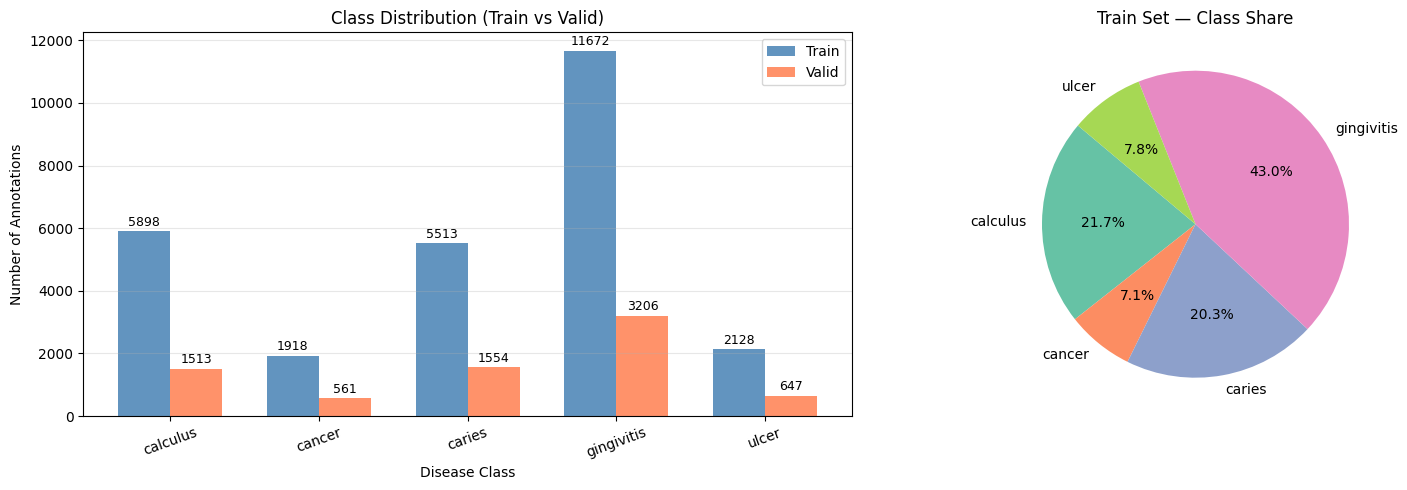

Saved: class_distribution.png


In [16]:
# Visualize class distribution
train_counts = [all_counts['train'].get(i, 0) for i in range(NUM_CLASSES)]
valid_counts = [all_counts['valid'].get(i, 0) for i in range(NUM_CLASSES)]

x = np.arange(NUM_CLASSES)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
ax = axes[0]
bars1 = ax.bar(x - width/2, train_counts, width, label='Train', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, valid_counts, width, label='Valid', color='coral',     alpha=0.85)
ax.set_xlabel('Disease Class')
ax.set_ylabel('Number of Annotations')
ax.set_title('Class Distribution (Train vs Valid)')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20)
ax.legend()
ax.bar_label(bars1, padding=2, fontsize=9)
ax.bar_label(bars2, padding=2, fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Pie chart for train
ax2 = axes[1]
colors = plt.cm.Set2.colors
ax2.pie(train_counts, labels=CLASS_NAMES, autopct='%1.1f%%', colors=colors[:NUM_CLASSES], startangle=140)
ax2.set_title('Train Set — Class Share')

plt.tight_layout()
plt.savefig('/kaggle/working/oral_dataset/oral_dataset/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

## ✅ Step 4: Create Kaggle-Compatible `data.yaml`

In [17]:
YAML_PATH = '/kaggle/working/oral_dataset/oral_dataset/data.yaml'

data_yaml = {
    'path' : DATASET_ROOT,
    'train': os.path.join(DATASET_ROOT, 'train', 'images'),
    'val'  : os.path.join(DATASET_ROOT, 'valid', 'images'),
    'test' : os.path.join(DATASET_ROOT, 'test',  'images'),
    'nc'   : NUM_CLASSES,
    'names': CLASS_NAMES
}

with open(YAML_PATH, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print("✅ data.yaml written to:", YAML_PATH)
print("\n--- Contents ---")
with open(YAML_PATH) as f:
    print(f.read())

✅ data.yaml written to: /kaggle/working/oral_dataset/oral_dataset/data.yaml

--- Contents ---
path: /kaggle/working/oral_dataset/oral_dataset
train: /kaggle/working/oral_dataset/oral_dataset/train/images
val: /kaggle/working/oral_dataset/oral_dataset/valid/images
test: /kaggle/working/oral_dataset/oral_dataset/test/images
nc: 5
names:
- calculus
- cancer
- caries
- gingivitis
- ulcer



## ✅ Step 5: Visualize Sample Images with Bounding Boxes

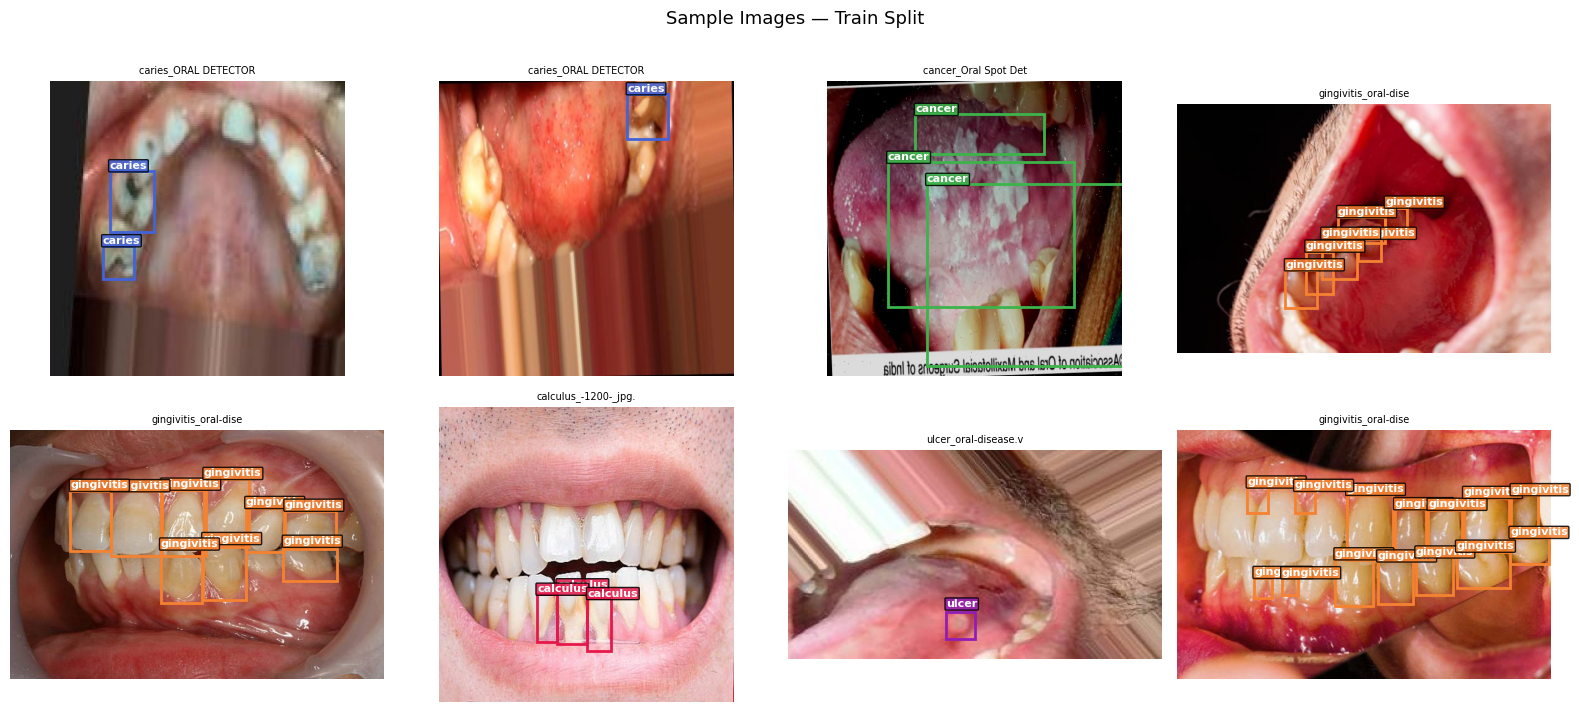

In [18]:
def yolo_to_pixel(box, w, h):
    """Convert YOLO [cx, cy, bw, bh] (normalized) → [x1, y1, x2, y2] (pixel)."""
    cx, cy, bw, bh = box
    x1 = (cx - bw / 2) * w
    y1 = (cy - bh / 2) * h
    x2 = (cx + bw / 2) * w
    y2 = (cy + bh / 2) * h
    return x1, y1, x2 - x1, y2 - y1   # x, y, width, height

COLORS = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4']

def show_samples(split='train', n=8):
    img_dir = split_info[split]['img_dir']
    lbl_dir = split_info[split]['lbl_dir']
    imgs = glob.glob(os.path.join(img_dir, '*.jpg')) + \
           glob.glob(os.path.join(img_dir, '*.jpeg')) + \
           glob.glob(os.path.join(img_dir, '*.png'))
    random.shuffle(imgs)
    imgs = imgs[:n]

    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
    axes = axes.flatten()

    for i, img_path in enumerate(imgs):
        img = Image.open(img_path).convert('RGB')
        W, H = img.size
        ax = axes[i]
        ax.imshow(img)

        # Load corresponding label
        stem = Path(img_path).stem
        lbl_path = os.path.join(lbl_dir, stem + '.txt')
        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if not parts:
                        continue
                    cls = int(parts[0])
                    box = list(map(float, parts[1:5]))
                    x, y, bw, bh = yolo_to_pixel(box, W, H)
                    rect = patches.Rectangle(
                        (x, y), bw, bh,
                        linewidth=2, edgecolor=COLORS[cls % len(COLORS)], facecolor='none'
                    )
                    ax.add_patch(rect)
                    ax.text(x, max(y - 4, 0), CLASS_NAMES[cls],
                            color='white', fontsize=8, weight='bold',
                            bbox=dict(boxstyle='round,pad=0.1', fc=COLORS[cls % len(COLORS)], alpha=0.85))

        ax.axis('off')
        ax.set_title(stem[:20], fontsize=7)

    for j in range(len(imgs), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Sample Images — {split.capitalize()} Split', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/oral_dataset/oral_dataset/samples_{split}.png', dpi=120, bbox_inches='tight')
    plt.show()

show_samples('train', n=8)

## ✅ Step 6: Train YOLOv8 Model

> 💡 **Model choice guide:**
> - `yolov8n.pt` → fastest, least accurate (good for quick tests)
> - `yolov8s.pt` → small + fast ✅ (good default)
> - `yolov8m.pt` → medium accuracy/speed balance
> - `yolov8l.pt` → large, best accuracy (needs more VRAM)
> - `yolov8x.pt` → extra-large (slowest)

In [19]:
# ─────────────────────────────────────────────────────────
# 🔧 TRAINING CONFIGURATION — Adjust as needed
# ─────────────────────────────────────────────────────────
MODEL_VARIANT = 'yolov8s.pt'   # options: yolov8n/s/m/l/x.pt
EPOCHS        = 100             # increase to 150-200 for best results
IMG_SIZE      = 640             # standard YOLO input size
BATCH_SIZE    = 16              # reduce to 8 if GPU OOM
PATIENCE      = 20              # early stopping patience
PROJECT_NAME  = 'dental_yolo'   # output folder name
RUN_NAME      = 'yolov8s_run1'  # experiment name
# ─────────────────────────────────────────────────────────

# Load pretrained model
model = YOLO(MODEL_VARIANT)
print(f"✅ Loaded model: {MODEL_VARIANT}")
print(f"   Parameters  : {sum(p.numel() for p in model.model.parameters()):,}")

✅ Loaded model: yolov8s.pt
   Parameters  : 11,166,560


In [20]:
# ─── TRAIN ───────────────────────────────────────────────
results = model.train(
    data        = YAML_PATH,
    epochs      = EPOCHS,
    imgsz       = IMG_SIZE,
    batch       = BATCH_SIZE,
    patience    = PATIENCE,
    project      = '/kaggle/working/oral_runs',
    name        = RUN_NAME,
    device      = 0 if torch.cuda.is_available() else 'cpu',
    workers     = 4,
    optimizer   = 'AdamW',
    lr0         = 0.001,
    lrf         = 0.01,
    momentum    = 0.937,
    weight_decay= 0.0005,
    warmup_epochs=3,
    # Augmentation
    hsv_h       = 0.015,
    hsv_s       = 0.7,
    hsv_v       = 0.4,
    degrees     = 15.0,
    translate   = 0.1,
    scale       = 0.5,
    fliplr      = 0.5,
    mosaic      = 1.0,
    mixup       = 0.1,
    # Logging
    plots       = True,
    save        = True,
    save_period = 10,       # save checkpoint every 10 epochs
    verbose     = True,
)

print("\n✅ Training complete!")
TRAIN_DIR = results.save_dir
print(f"   Results saved to: {TRAIN_DIR}")

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/oral_dataset/oral_dataset/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_run1, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, ov

## ✅ Step 7: Evaluate on Validation & Test Sets

In [21]:
# Load best weights
BEST_WEIGHTS = os.path.join(TRAIN_DIR, 'weights', 'best.pt')
print(f"Loading best weights: {BEST_WEIGHTS}")
best_model = YOLO(BEST_WEIGHTS)

# ── Validation set metrics
print("\n📊 Evaluating on Validation Set...")
val_results = best_model.val(
    data    = YAML_PATH,
    split   = 'val',
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    device  = 0 if torch.cuda.is_available() else 'cpu',
    verbose = True,
    plots   = True,
)

print("\n✅ Validation Metrics:")
print(f"   mAP50       : {val_results.box.map50:.4f}")
print(f"   mAP50-95    : {val_results.box.map:.4f}")
print(f"   Precision   : {val_results.box.mp:.4f}")
print(f"   Recall      : {val_results.box.mr:.4f}")

Loading best weights: /kaggle/working/oral_runs/yolov8s_run1/weights/best.pt

📊 Evaluating on Validation Set...
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 843.2±600.0 MB/s, size: 34.6 KB)
val: Scanning /kaggle/working/oral_dataset/oral_dataset/valid/labels.cache... 1720 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1720/1720 554.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 4.9it/s 22.0s0.2s
                   all       1720       7481       0.62       0.63      0.636      0.309
              calculus        241       1513      0.624      0.727      0.717      0.392
                cancer        352        561      0.446      0.152      0.229     0.0696
                caries        509       1554      0.609      0.723      0.699 

In [22]:
# ── Test set metrics
print("\n📊 Evaluating on Test Set...")
test_results = best_model.val(
    data    = YAML_PATH,
    split   = 'test',
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    device  = 0 if torch.cuda.is_available() else 'cpu',
    verbose = True,
    plots   = True,
)

print("\n✅ Test Set Metrics:")
print(f"   mAP50       : {test_results.box.map50:.4f}")
print(f"   mAP50-95    : {test_results.box.map:.4f}")
print(f"   Precision   : {test_results.box.mp:.4f}")
print(f"   Recall      : {test_results.box.mr:.4f}")


📊 Evaluating on Test Set...
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 646.3±325.6 MB/s, size: 30.1 KB)
val: Scanning /kaggle/working/oral_dataset/oral_dataset/test/labels... 867 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 867/867 1.3Kit/s 0.7s0.1ss
val: New cache created: /kaggle/working/oral_dataset/oral_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 55/55 4.5it/s 12.2s0.2s
                   all        867       3751      0.631      0.639      0.635       0.31
              calculus        122        798      0.669      0.702      0.706      0.385
                cancer        176        276      0.498      0.181      0.253     0.0772
                caries        256        777      0.587      0.753      0.681      0.312
            gingivitis        159       1576      0.584      0.683      0.646  

In [23]:
# ── Per-class AP table
print("\n📊 Per-Class Metrics (Validation):")
print("-" * 55)
print(f"  {'Class':<15}  {'AP50':>8}  {'AP50-95':>9}")
print("-" * 55)

try:
    maps = val_results.box.maps        # per-class mAP50-95
    ap50s = val_results.box.ap50       # per-class AP50
    for i, name in enumerate(CLASS_NAMES):
        print(f"  {name:<15}  {ap50s[i]:>8.4f}  {maps[i]:>9.4f}")
except Exception as e:
    print(f"  (per-class detail unavailable: {e})")
print("-" * 55)


📊 Per-Class Metrics (Validation):
-------------------------------------------------------
  Class                AP50    AP50-95
-------------------------------------------------------
  calculus           0.7169     0.3921
  cancer             0.2289     0.0696
  caries             0.6994     0.3159
  gingivitis         0.6467     0.3168
  ulcer              0.8895     0.4515
-------------------------------------------------------


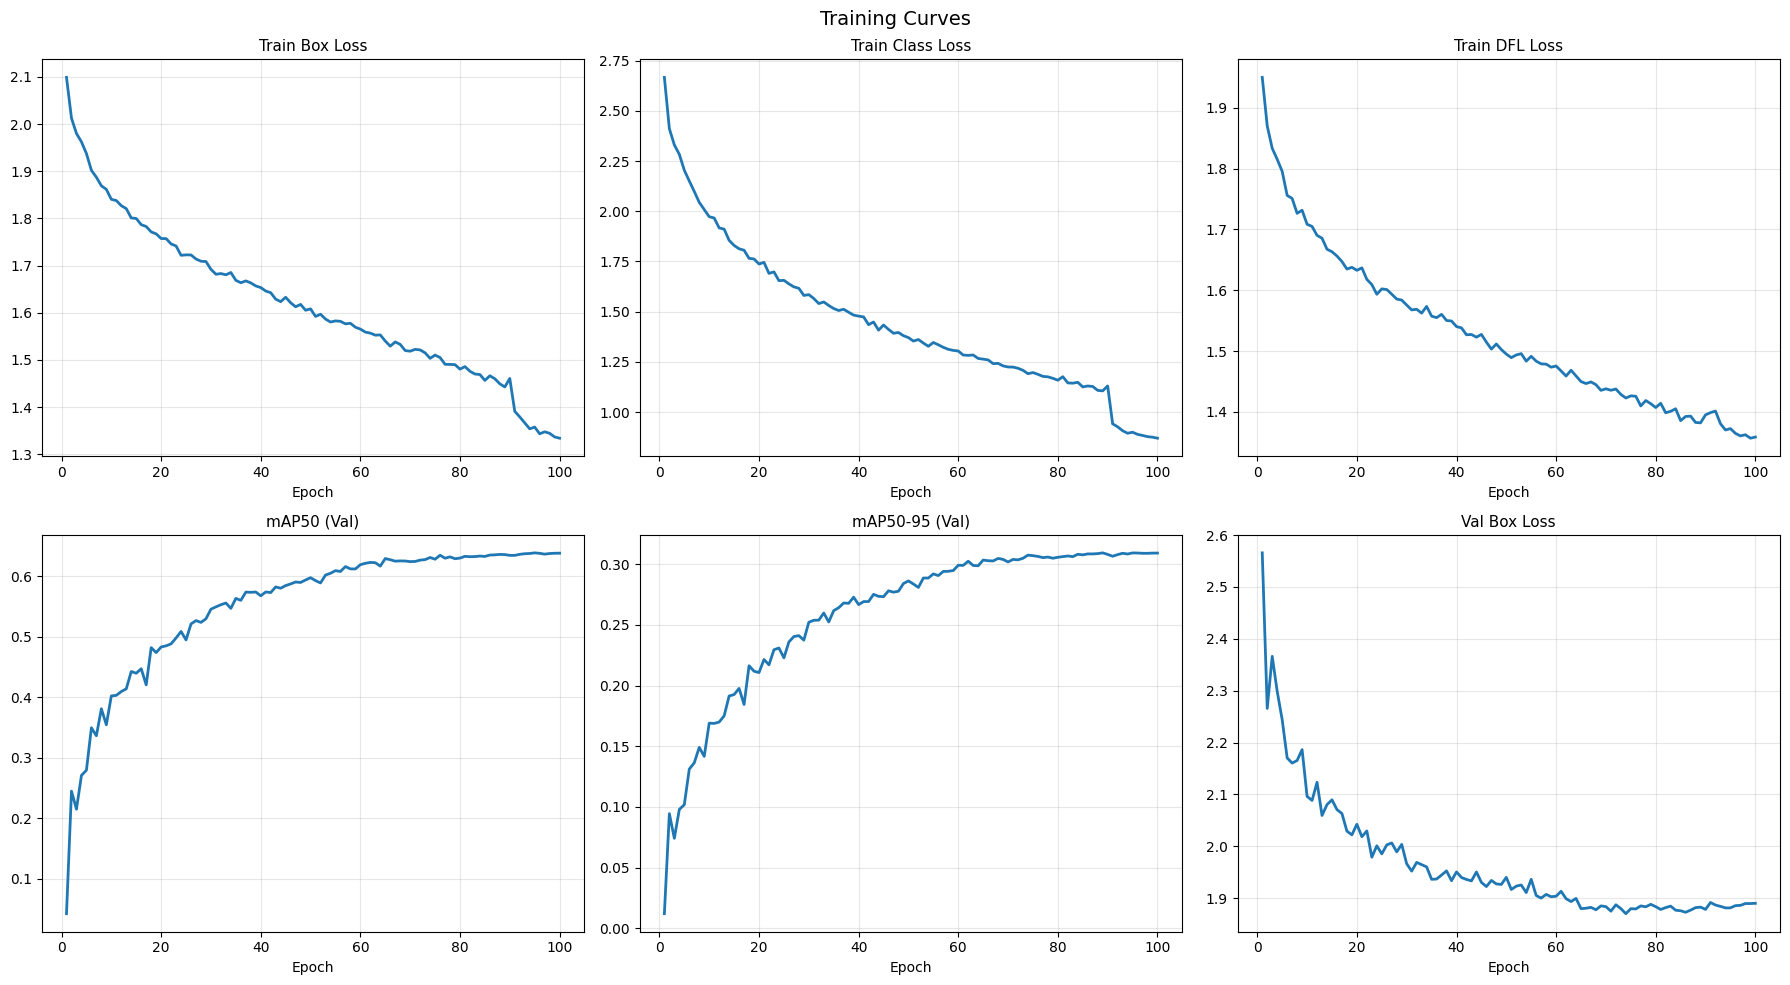

Saved: training_curves.png


In [24]:
# Plot training curves from results.csv
import pandas as pd

results_csv = os.path.join(TRAIN_DIR, 'results.csv')
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    metrics = [
        ('train/box_loss',  'Train Box Loss',        axes[0][0]),
        ('train/cls_loss',  'Train Class Loss',      axes[0][1]),
        ('train/dfl_loss',  'Train DFL Loss',        axes[0][2]),
        ('metrics/mAP50(B)','mAP50 (Val)',           axes[1][0]),
        ('metrics/mAP50-95(B)', 'mAP50-95 (Val)',   axes[1][1]),
        ('val/box_loss',    'Val Box Loss',           axes[1][2]),
    ]

    for col, title, ax in metrics:
        if col in df.columns:
            ax.plot(df['epoch'], df[col], linewidth=2)
            ax.set_title(title, fontsize=11)
            ax.set_xlabel('Epoch')
            ax.grid(alpha=0.3)
        else:
            ax.set_title(f'{title} (N/A)')
            ax.axis('off')

    plt.suptitle('Training Curves', fontsize=14)
    plt.tight_layout()
    plt.savefig('/kaggle/working/oral_dataset/oral_dataset/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: training_curves.png")
else:
    print("results.csv not found — skipping curves plot.")

## ✅ Step 8: Run Predictions & Visualize Results

In [25]:
# Predict on test images
TEST_IMG_DIR    = split_info['test']['img_dir']
PRED_OUTPUT_DIR = '/kaggle/working/oral_dataset/oral_dataset/predictions'

print(f"Running inference on: {TEST_IMG_DIR}")
pred_results = best_model.predict(
    source     = TEST_IMG_DIR,
    imgsz      = IMG_SIZE,
    conf       = 0.25,          # confidence threshold
    iou        = 0.45,          # NMS IoU threshold
    save       = True,
    save_txt   = True,
    save_conf  = True,
    project    = PRED_OUTPUT_DIR,
    name       = 'results',
    device     = 0 if torch.cuda.is_available() else 'cpu',
    verbose    = False,
)

print(f"\n✅ Predictions saved to: {PRED_OUTPUT_DIR}")

Running inference on: /kaggle/working/oral_dataset/oral_dataset/test/images
Results saved to /kaggle/working/oral_dataset/oral_dataset/predictions/results
747 labels saved to /kaggle/working/oral_dataset/oral_dataset/predictions/results/labels

✅ Predictions saved to: /kaggle/working/oral_dataset/oral_dataset/predictions


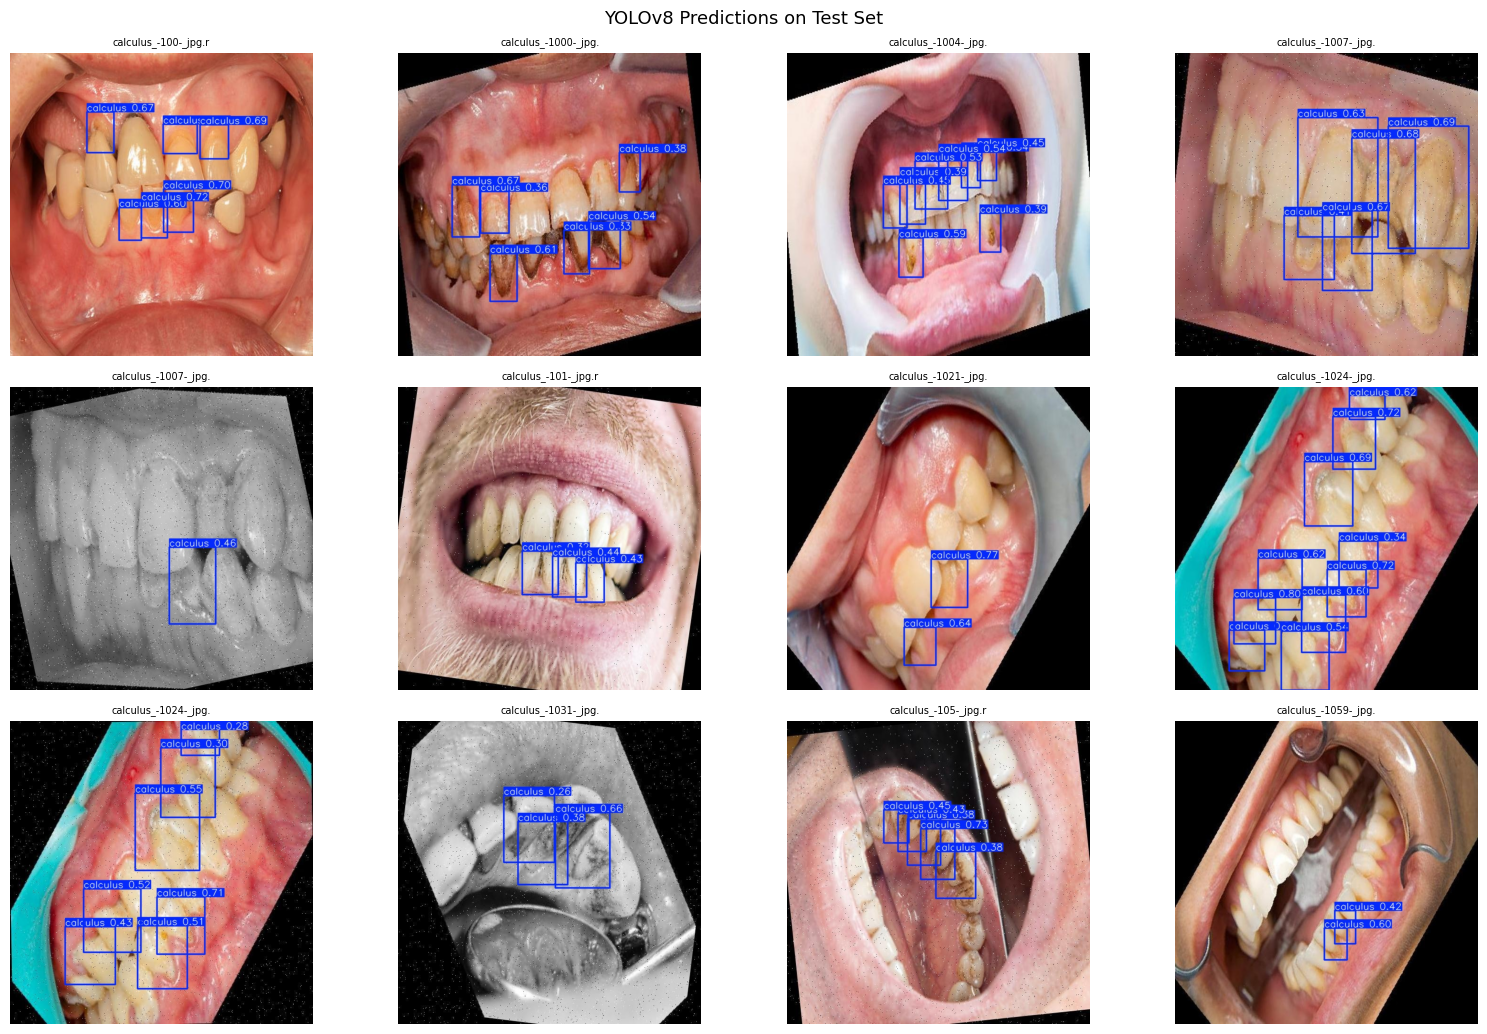

Saved: predictions_grid.png


In [26]:
# Visualize 12 prediction results
pred_img_dir = os.path.join(PRED_OUTPUT_DIR, 'results')
pred_imgs = glob.glob(os.path.join(pred_img_dir, '*.jpg')) + \
            glob.glob(os.path.join(pred_img_dir, '*.png'))
pred_imgs = sorted(pred_imgs)[:12]

if pred_imgs:
    cols = 4
    rows = (len(pred_imgs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
    axes = axes.flatten()
    for i, p in enumerate(pred_imgs):
        img = Image.open(p)
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(Path(p).stem[:20], fontsize=7)
    for j in range(len(pred_imgs), len(axes)):
        axes[j].axis('off')
    plt.suptitle('YOLOv8 Predictions on Test Set', fontsize=13)
    plt.tight_layout()
    plt.savefig('/kaggle/working/oral_dataset/oral_dataset/predictions_grid.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Saved: predictions_grid.png")
else:
    print("No predicted images found — check PRED_OUTPUT_DIR.")

In [27]:
# ── Detection count by class
class_detect_counts = Counter()
for r in pred_results:
    if r.boxes is not None:
        for cls in r.boxes.cls.cpu().numpy():
            class_detect_counts[int(cls)] += 1

print("\n📊 Total Detections on Test Set (conf >= 0.25):")
print("-" * 35)
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<15} : {class_detect_counts.get(i, 0):>5}")
print("-" * 35)
print(f"  {'TOTAL':<15} : {sum(class_detect_counts.values()):>5}")


📊 Total Detections on Test Set (conf >= 0.25):
-----------------------------------
  calculus        :   755
  cancer          :    68
  caries          :   894
  gingivitis      :  1598
  ulcer           :   315
-----------------------------------
  TOTAL           :  3630


## ✅ Step 9: Export & Save Best Model to Drive

In [29]:

SAVE_DIR = '/kaggle/working/final_results'
os.makedirs(SAVE_DIR, exist_ok=True)

# Copy weights
shutil.copy(BEST_WEIGHTS, f'{SAVE_DIR}/best.pt')

last_weights = os.path.join(TRAIN_DIR, 'weights', 'last.pt')
if os.path.exists(last_weights):
    shutil.copy(last_weights, f'{SAVE_DIR}/last.pt')

# Copy YOLO result files
for f in [
    'results.csv', 'confusion_matrix.png', 'PR_curve.png',
    'P_curve.png', 'R_curve.png', 'F1_curve.png',
    'val_batch0_pred.jpg'
]:
    src = os.path.join(TRAIN_DIR, f)
    if os.path.exists(src):
        shutil.copy(src, SAVE_DIR)

# Copy generated plots
for f in [
    'class_distribution.png',
    'training_curves.png',
    'predictions_grid.png',
    'samples_train.png'
]:
    src = f'/kaggle/working/oral_dataset/oral_dataset/{f}'
    if os.path.exists(src):
        shutil.copy(src, SAVE_DIR)

# Copy YAML
shutil.copy(YAML_PATH, SAVE_DIR)

# Show saved files
print(f"\n✅ Files saved to: {SAVE_DIR}\n")

for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1024
    print(f"{f:<35} {size:>8.1f} KB")


✅ Files saved to: /kaggle/working/final_results

best.pt                              21986.9 KB
class_distribution.png                 105.3 KB
confusion_matrix.png                   166.1 KB
data.yaml                                0.3 KB
last.pt                              21986.9 KB
predictions_grid.png                  2513.6 KB
results.csv                             11.8 KB
samples_train.png                     1439.0 KB
training_curves.png                    201.7 KB
val_batch0_pred.jpg                    408.8 KB


## ✅ Step 10: Final Summary

In [31]:
print(f"""
============================================================
🦷 DENTAL YOLOV8 — TRAINING SUMMARY
============================================================

Model          : {MODEL_VARIANT}
Classes        : {', '.join(CLASS_NAMES)}

Train images   : {split_info['train']['images']:,}
Valid images   : {split_info['valid']['images']:,}
Test images    : {split_info['test']['images']:,}

Epochs trained : {EPOCHS} (with early stopping)
Image size     : {IMG_SIZE}

Best weights   : {BEST_WEIGHTS}

------------------------------------------------------------

Val  mAP50     : {val_results.box.map50:.4f}
Val  mAP50-95  : {val_results.box.map:.4f}

Test mAP50     : {test_results.box.map50:.4f}
Test mAP50-95  : {test_results.box.map:.4f}

------------------------------------------------------------

Results saved  : {SAVE_DIR}

============================================================
✅ Done! Your trained model is ready.
============================================================
""")


🦷 DENTAL YOLOV8 — TRAINING SUMMARY

Model          : yolov8s.pt
Classes        : calculus, cancer, caries, gingivitis, ulcer

Train images   : 6,029
Valid images   : 1,720
Test images    : 867

Epochs trained : 100 (with early stopping)
Image size     : 640

Best weights   : /kaggle/working/oral_runs/yolov8s_run1/weights/best.pt

------------------------------------------------------------

Val  mAP50     : 0.6363
Val  mAP50-95  : 0.3092

Test mAP50     : 0.6351
Test mAP50-95  : 0.3103

------------------------------------------------------------

Results saved  : /kaggle/working/final_results

✅ Done! Your trained model is ready.



Results saved to /kaggle/working/oral_dataset/oral_dataset/predictions/results
747 labels saved to /kaggle/working/oral_dataset/oral_dataset/predictions/results/labels
Results saved to /kaggle/working/oral_dataset/oral_dataset/predictions/results
747 labels saved to /kaggle/working/oral_dataset/oral_dataset/predictions/results/labels
Results saved to /kaggle/working/oral_dataset/oral_dataset/predictions/results
747 labels saved to /kaggle/working/oral_dataset/oral_dataset/predictions/results/labels
Results saved to /kaggle/working/oral_dataset/oral_dataset/predictions/results
747 labels saved to /kaggle/working/oral_dataset/oral_dataset/predictions/results/labels
Results saved to /kaggle/working/oral_dataset/oral_dataset/predictions/results
747 labels saved to /kaggle/working/oral_dataset/oral_dataset/predictions/results/labels


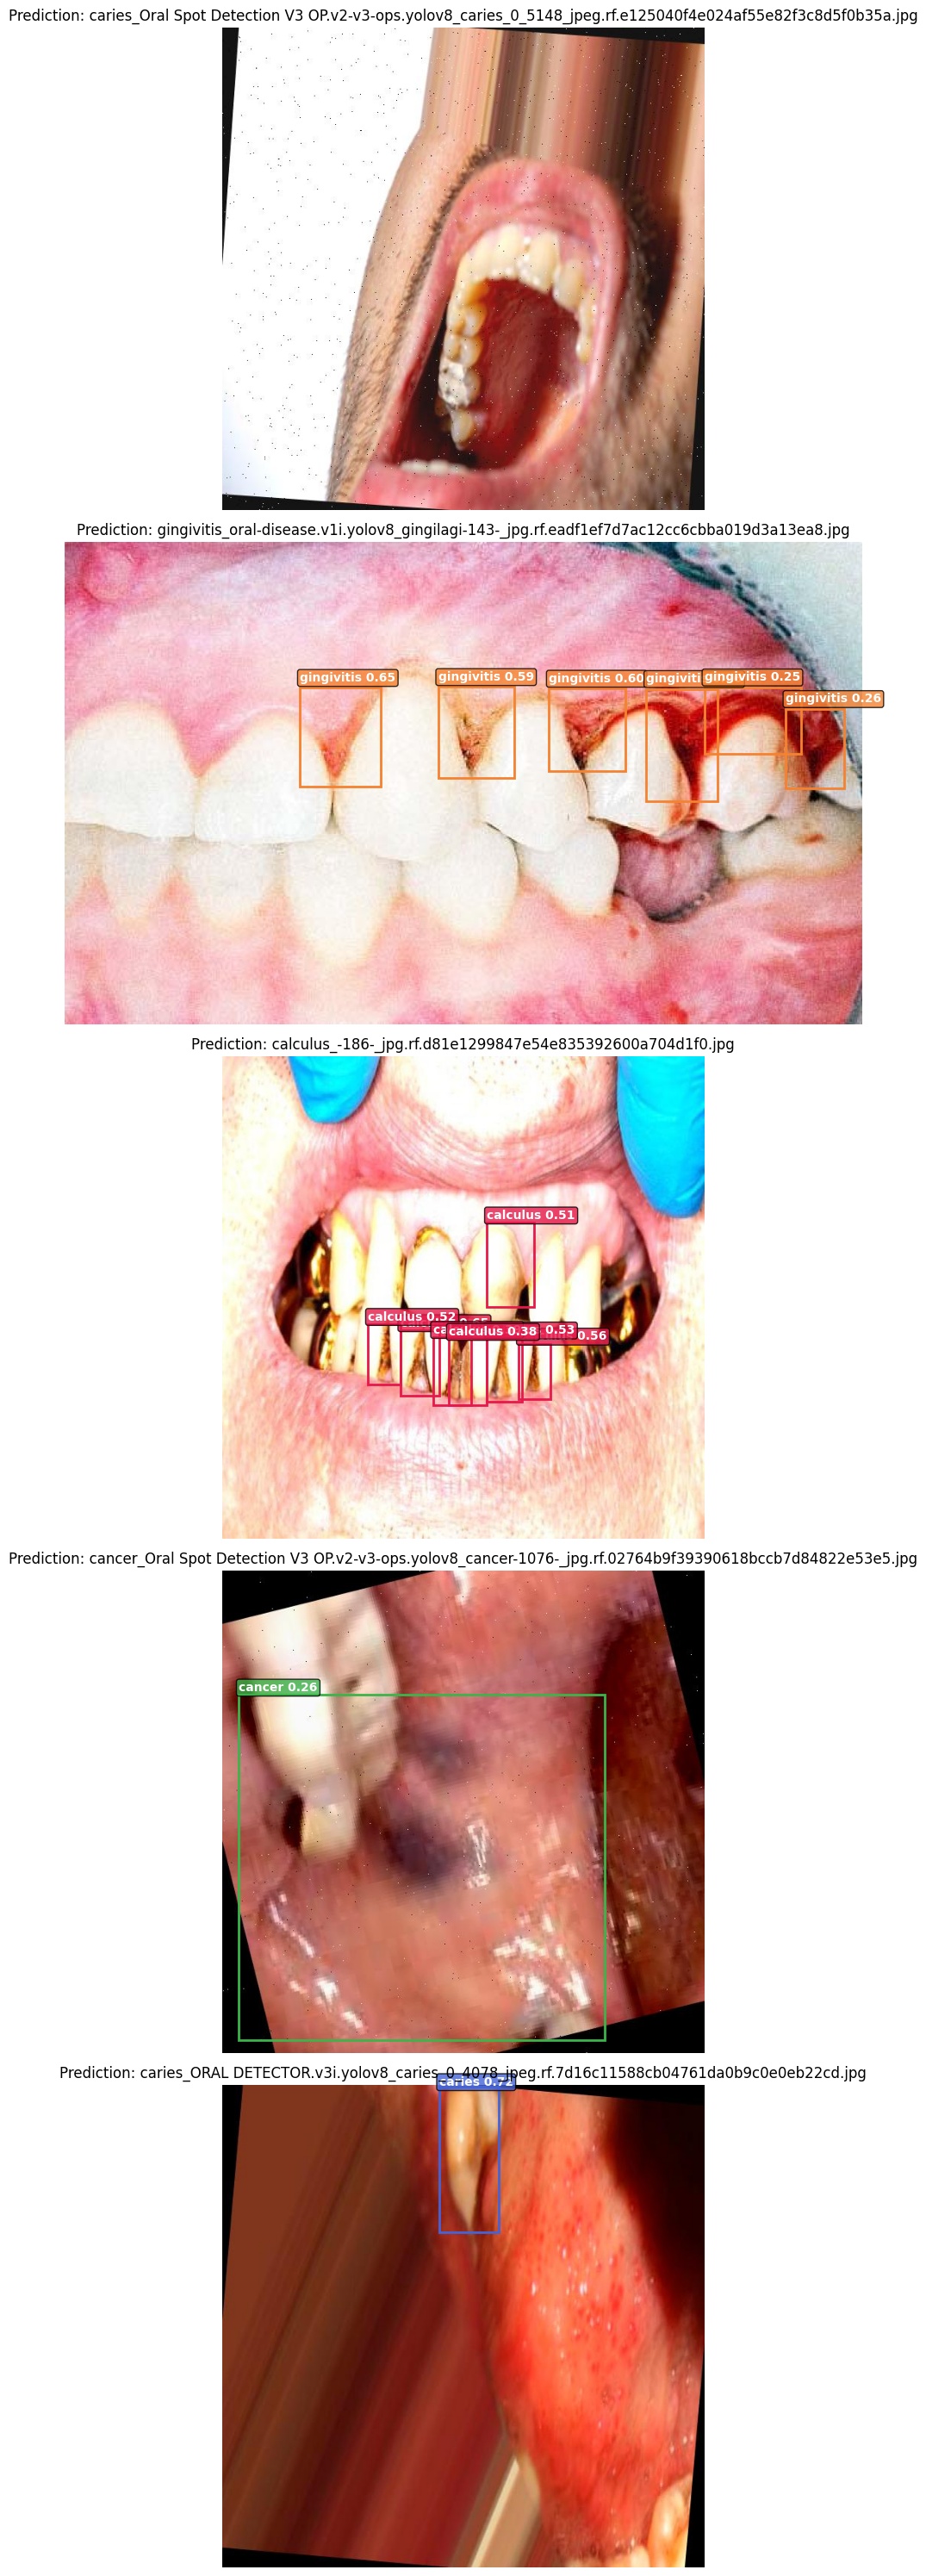


✅ Test predictions saved to /kaggle/working/final_results/test_predictions.png


In [33]:
# =========================================================
# TEST MODEL ON RANDOM TEST IMAGES (COMPACT)
# =========================================================

import os, random
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Config
TEST_IMAGES_DIR = '/kaggle/working/oral_dataset/oral_dataset/test/images'
SAMPLE_SIZE = 5

# Get random images
all_images = [f for f in os.listdir(TEST_IMAGES_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
sample_images = random.sample(all_images, min(SAMPLE_SIZE, len(all_images)))

# Predict and plot
fig, axes = plt.subplots(len(sample_images), 1, figsize=(10, 6 * len(sample_images)))
if len(sample_images) == 1: axes = [axes]

for ax, img_name in zip(axes, sample_images):
    result = best_model.predict(source=os.path.join(TEST_IMAGES_DIR, img_name), conf=0.25, iou=0.45, imgsz=IMG_SIZE, verbose=False)[0]
    img = Image.open(os.path.join(TEST_IMAGES_DIR, img_name)).convert('RGB')
    ax.imshow(img)
    
    if result.boxes:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            cls, conf = int(box.cls[0].item()), float(box.conf[0].item())
            ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=COLORS[cls], facecolor='none'))
            ax.text(x1, max(y1-5, 0), f'{CLASS_NAMES[cls]} {conf:.2f}', color='white', fontsize=10, weight='bold',
                   bbox=dict(boxstyle='round,pad=0.2', fc=COLORS[cls], alpha=0.8))
    
    ax.set_title(f'Prediction: {img_name}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/final_results/test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Test predictions saved to /kaggle/working/final_results/test_predictions.png")